In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1 Dataset: Fashion MNIST

Vi använder Fashion MNIST-datasetet som innehåller 28x28 pixlar gråskalebilder av klädesplagg.

Datan delas upp i träningsdata och testdata:

- Träningsdata används för att lära modellen
- Testdata används för att utvärdera modellen efter träning

In [2]:
# Laddar in Fashion MNIST-datasetet från Keras
fashion_mnist = keras.datasets.fashion_mnist

# Delar upp datan i träningsdata och testdata
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

### Datans struktur

Undersöker datans form för att förstå hur många bilder vi har och hur de är strukturerade.

Varje bild är 28x28 pixlar och lagras som en matris med siffror.

In [3]:
# Skriver ut form (shape) på tränings- och testdata för att förstå datans storlek
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)

print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


### Klassnamn

Eftersom labels i datan är siffror (0–9) använder vi en lista med klassnamn för att göra resultaten mer begripliga.

In [4]:
# Lista med klassnamn som motsvarar siffrorna (0–9) i datasetet
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

for i, name in enumerate(class_names):
    print(i, name)

0 T-shirt/top
1 Trouser
2 Pullover
3 Dress
4 Coat
5 Sandal
6 Shirt
7 Sneaker
8 Bag
9 Ankle boot


### Visualisering av en bild

Visar en enskild bild från datasetet för att förstå hur datan ser ut och hur den kopplas till rätt klass.

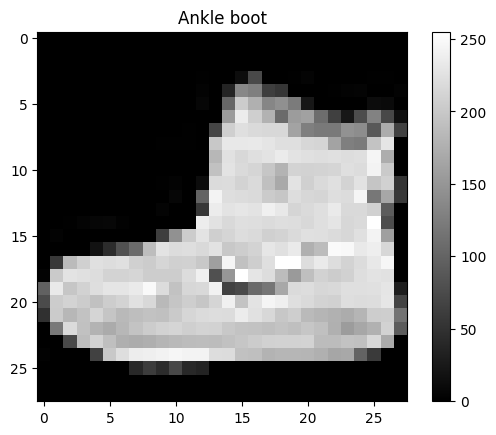

In [5]:
# Visar första bilden i träningsdatan
plt.imshow(X_train[0], cmap='gray')

# Lägger till titel med rätt klassnamn för bilden
plt.title(class_names[y_train[0]])

# Visar färgskalan (pixelvärden)
plt.colorbar()
plt.show()

### Flera exempelbilder

Visar flera bilder samtidigt för att få en bättre känsla för variationen i datasetet och hur olika klasser ser ut.

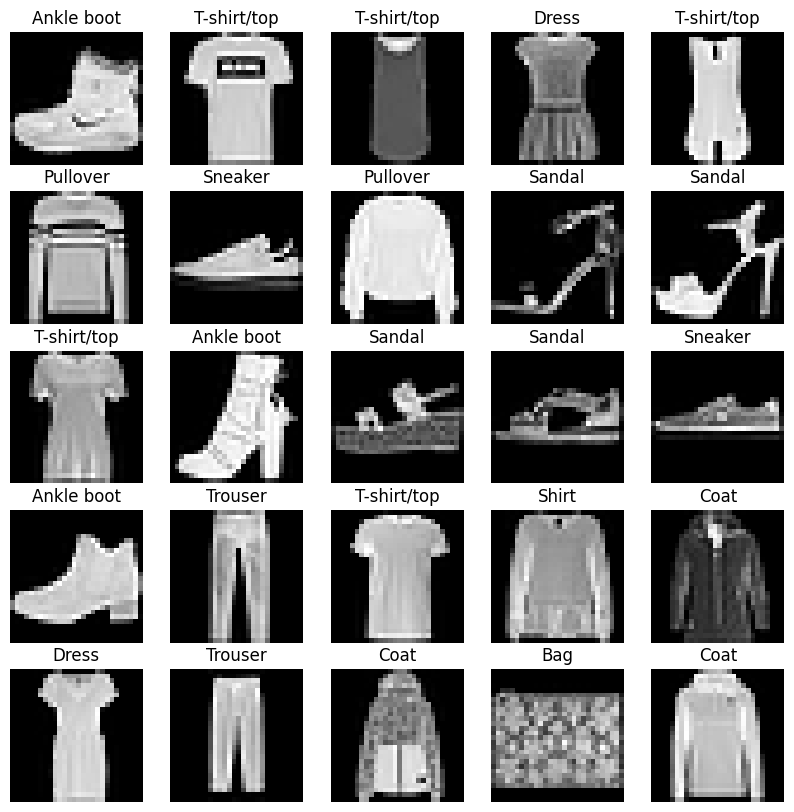

In [6]:
# Visar de första 25 bilderna i träningsdatan i ett 5x5 rutnät,
# tillsammans med respektive klassnamn för att enkelt kunna koppla bild till kategori
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

### Klassfördelning

Räknar antal bilder per klass för att se om datasetet är balanserat.

Ett balanserat dataset är viktigt eftersom modellen då tränas jämnt på alla klasser.

In [7]:
# Räknar hur många bilder som finns i varje klass i träningsdatan
unique, counts = np.unique(y_train, return_counts=True)

# Skriver ut antal bilder per klass för att kontrollera datans fördelning
for label, count in zip(unique, counts):
    print(class_names[label], ':', count)

T-shirt/top : 6000
Trouser : 6000
Pullover : 6000
Dress : 6000
Coat : 6000
Sandal : 6000
Shirt : 6000
Sneaker : 6000
Bag : 6000
Ankle boot : 6000


## 2 Dataförberedelse

In [8]:
# Skapa valideringsset

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (48000, 28, 28)
X_val: (12000, 28, 28)
y_train: (48000,)
y_val: (12000,)


In [9]:
# Lägga till kanal-dimension till X_train

X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train shape efter kanal-dimension:", X_train.shape)
print("X_val shape efter kanal-dimension:", X_val.shape)
print("X_test shape efter kanal-dimension:", X_test.shape)

X_train shape efter kanal-dimension: (48000, 28, 28, 1)
X_val shape efter kanal-dimension: (12000, 28, 28, 1)
X_test shape efter kanal-dimension: (10000, 28, 28, 1)


In [10]:
# Normalisera

X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0

X_test_norm = X_test.astype("float32") / 255.0

print("X_train min/max:", X_train.min(), X_train.max())
print("X_val min/max:", X_val.min(), X_val.max())
print("X_test min/max:", X_test_norm.min(), X_test_norm.max())
print("X_train shape:", X_train.shape)

X_train min/max: 0.0 1.0
X_val min/max: 0.0 1.0
X_test min/max: 0.0 1.0
X_train shape: (48000, 28, 28, 1)


## 3 Bygg en modell

Som standard valdes Adam med inlärningshastigheten 0,001 och batchsize = 32.

In [11]:
# Basmodell

baseline_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])


## 4 Träna modellen

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8540 - loss: 0.4089 - val_accuracy: 0.8846 - val_loss: 0.3207
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9011 - loss: 0.2746 - val_accuracy: 0.8967 - val_loss: 0.2849
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9172 - loss: 0.2261 - val_accuracy: 0.9023 - val_loss: 0.2725
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9325 - loss: 0.1879 - val_accuracy: 0.9053 - val_loss: 0.2686
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9437 - loss: 0.1563 - val_accuracy: 0.9052 - val_loss: 0.2724
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9538 - loss: 0.1293 - val_accuracy: 0.9051 - val_loss: 0.2901
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9628 - loss: 0.1066 - val_accuracy: 0.9058 - val_loss: 0.3023

Resultat för Basmodell:
Antal epoker:        7
Train accuracy:      0.9628
Train l

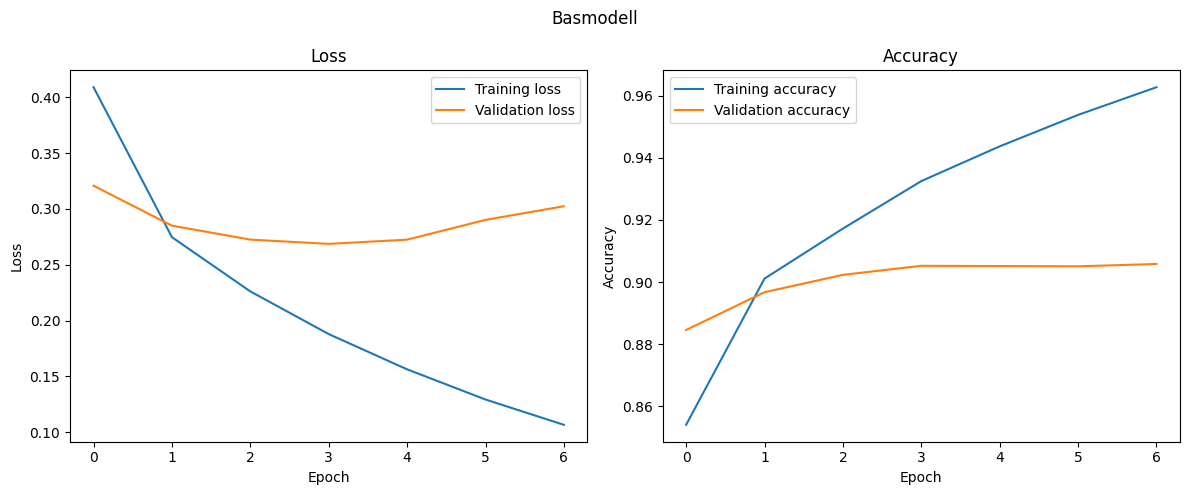

     name  train_accuracy  train_loss  validation_accuracy  validation_loss  epochs_trained  training_time
Basmodell         0.96275    0.106622             0.905833         0.302344               7      76.455451


In [12]:
# Compilerar och tränar basmodellen

from utils_malin_test import model_compile_and_fit
from utils_malin_test import plot_history

results = []

model_bas, h_bas, r_bas = model_compile_and_fit(baseline_model, X_train, y_train, X_val, y_val, name="Basmodell")
results.append(r_bas)

print(pd.DataFrame(results).to_string(index=False))

### Analys av basmodell

Basmodellen når en accuracy på trainingdatan på 0,956 och på validationdatan på 0,909 efter 7 epoker och kurvorna visar överanpassning tidigt. 

## 5 Testa och förbättra modellen

Basmodellen utökades först med ett till Conv2D-lager.

In [13]:
# Förbättrad modell med ett till Conv2D-block

improved_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu",),
    layers.Dense(10, activation="softmax")
])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8483 - loss: 0.4197 - val_accuracy: 0.8813 - val_loss: 0.3234
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9006 - loss: 0.2723 - val_accuracy: 0.9043 - val_loss: 0.2635
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9178 - loss: 0.2239 - val_accuracy: 0.9125 - val_loss: 0.2499
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9314 - loss: 0.1876 - val_accuracy: 0.9139 - val_loss: 0.2455
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9421 - loss: 0.1573 - val_accuracy: 0.9163 - val_loss: 0.2484
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9527 - loss: 0.1305 - val_accuracy: 0.9170 - val_loss: 0.2577
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9605 - loss: 0.1082 - val_accuracy: 0.9173 - val_loss: 0.2698

Resultat för Förbättrad modell:
Antal epoker:        7
Train accuracy:      0.9605

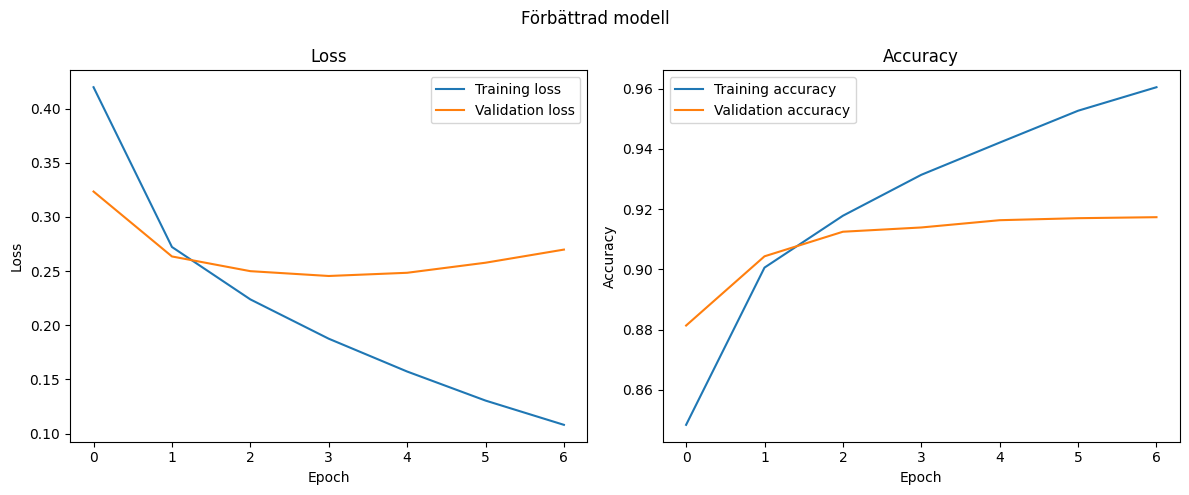

             name  train_accuracy  train_loss  validation_accuracy  validation_loss  epochs_trained  training_time
        Basmodell        0.962750    0.106622             0.905833         0.302344               7      76.455451
Förbättrad modell        0.960521    0.108154             0.917333         0.269844               7      82.896507


In [14]:
# Compilerar och tränar förbättrad modell

model_imp, h_imp, r_imp = model_compile_and_fit(improved_model, X_train, y_train, X_val, y_val, name="Förbättrad modell")
results.extend([r_imp])

print(pd.DataFrame(results).to_string(index=False))

### Analys av förbättrad modell

Det extra Conv2D-lagret ger en något bättre accuracy på validationdatan på 0,913 men kurvorna uppvisar samma mönster av överanpassning som i basmodellen.  

För att minska överanpassningen testades att lägga till dropout.

In [15]:
# Ytterligare förbättrad modell med dropout

improved_model2 = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu",),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8317 - loss: 0.4712 - val_accuracy: 0.8850 - val_loss: 0.3118
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8880 - loss: 0.3090 - val_accuracy: 0.9004 - val_loss: 0.2687
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9049 - loss: 0.2583 - val_accuracy: 0.9119 - val_loss: 0.2415
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9149 - loss: 0.2277 - val_accuracy: 0.9137 - val_loss: 0.2527
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9252 - loss: 0.2010 - val_accuracy: 0.9187 - val_loss: 0.2332
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9334 - loss: 0.1793 - val_accuracy: 0.9195 - val_loss: 0.2352
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9396 - loss: 0.1605 - val_accuracy: 0.9198 - val_loss: 0.2384
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9460 - loss: 0

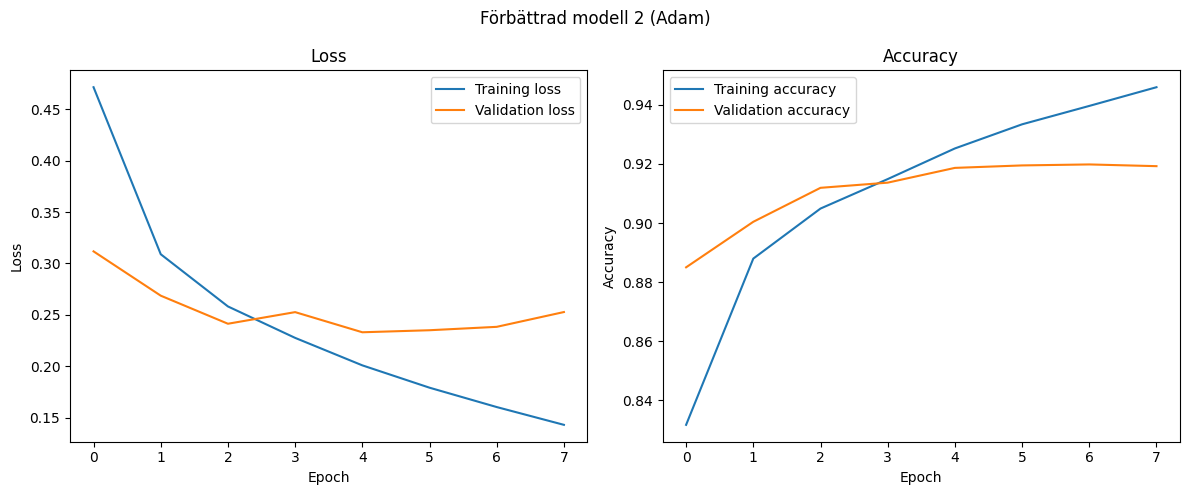

                      name  train_accuracy  train_loss  validation_accuracy  validation_loss  epochs_trained  training_time
                 Basmodell        0.962750    0.106622             0.905833         0.302344               7      76.455451
         Förbättrad modell        0.960521    0.108154             0.917333         0.269844               7      82.896507
Förbättrad modell 2 (Adam)        0.945979    0.143244             0.919250         0.252821               8     103.992963


In [ ]:
# Compilerar och tränar förbättrad modell 2

model_imp2, h_imp2, r_imp2 = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="Förbättrad modell 2")
results.append(r_imp2)

print(pd.DataFrame(results).to_string(index=False))

### Analys av förbättrad modell 2

Med dropout så fås lägre accuracy på trainingdatan 0,938 jämfört med 0,959 men gapet mot accuracy på valideringsdatan är mindre. Loss på valideringsdatan har minskat från 0,302 till 0,261. Tränings- och valideringskurvorna följer varandra bättre. Denna modell generaliserar bättre än de tidigare.

## 6 Fördjupning i fokusområde optimerare och inlärningshastighet

Tre olika optimerare testas med tre olika inlärningshastigheter.

### Adam med LR 0,0001, 0,001 och 0,01

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7502 - loss: 0.7139 - val_accuracy: 0.8461 - val_loss: 0.4400
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8384 - loss: 0.4536 - val_accuracy: 0.8664 - val_loss: 0.3764
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8607 - loss: 0.3921 - val_accuracy: 0.8798 - val_loss: 0.3383
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8700 - loss: 0.3611 - val_accuracy: 0.8832 - val_loss: 0.3209
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8805 - loss: 0.3334 - val_accuracy: 0.8910 - val_loss: 0.2985
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8867 - loss: 0.3185 - val_accuracy: 0.8938 - val_loss: 0.2885
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8915 - loss: 0.3033 - val_accuracy: 0.8981 - val_loss: 0.2777
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8957 - loss: 

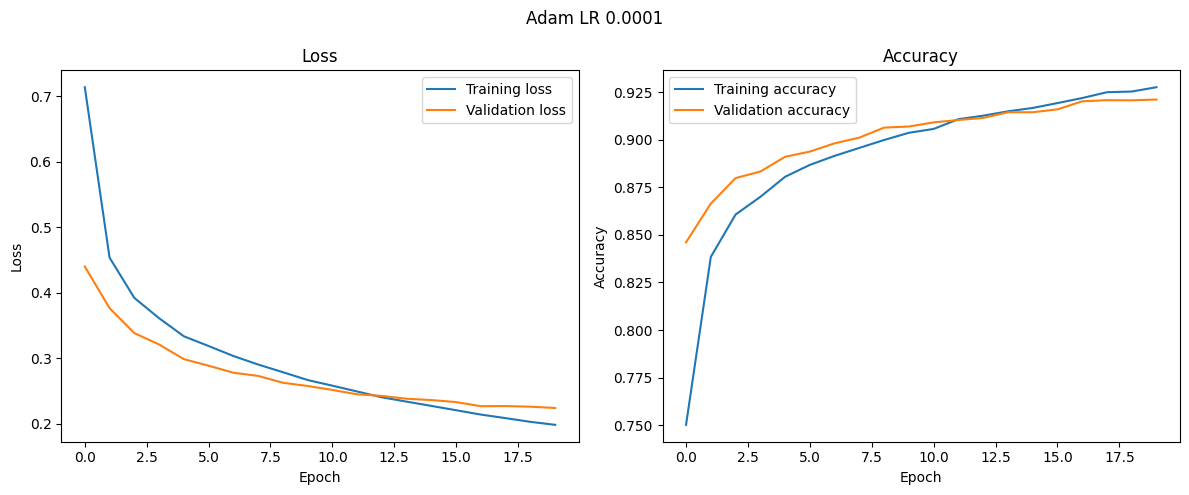

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8317 - loss: 0.4712 - val_accuracy: 0.8850 - val_loss: 0.3118
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8880 - loss: 0.3090 - val_accuracy: 0.9004 - val_loss: 0.2687
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9049 - loss: 0.2583 - val_accuracy: 0.9119 - val_loss: 0.2415
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9149 - loss: 0.2277 - val_accuracy: 0.9137 - val_loss: 0.2527
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9252 - loss: 0.2010 - val_accuracy: 0.9187 - val_loss: 0.2332
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9334 - loss: 0.1793 - val_accuracy: 0.9195 - val_loss: 0.2352
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9396 - loss: 0.1605 - val_accuracy: 0.9198 - val_loss: 0.2384
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9460 - loss: 0

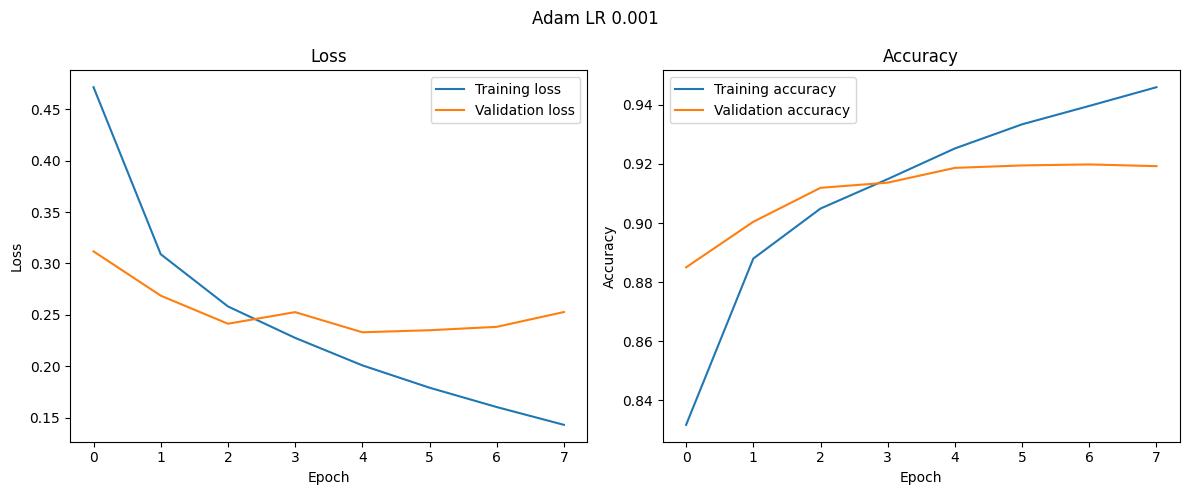

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8240 - loss: 0.4864 - val_accuracy: 0.8603 - val_loss: 0.3685
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8578 - loss: 0.3893 - val_accuracy: 0.8737 - val_loss: 0.3486
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8641 - loss: 0.3690 - val_accuracy: 0.8717 - val_loss: 0.3514
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8655 - loss: 0.3625 - val_accuracy: 0.8874 - val_loss: 0.3123
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8698 - loss: 0.3532 - val_accuracy: 0.8742 - val_loss: 0.3533
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8707 - loss: 0.3516 - val_accuracy: 0.8882 - val_loss: 0.3187
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8732 - loss: 0.3412 - val_accuracy: 0.8803 - val_loss: 0.3384

Resultat för Adam LR 0.01:
Antal epoker:        7
Train accuracy:      0.8732
Trai

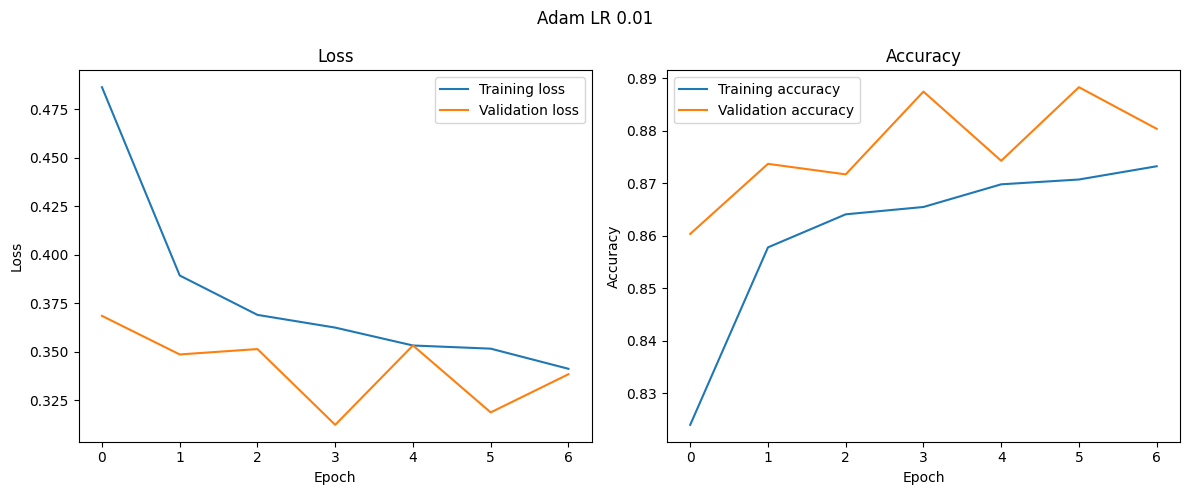

                      name  train_accuracy  train_loss  validation_accuracy  validation_loss  epochs_trained  training_time
                 Basmodell        0.962750    0.106622             0.905833         0.302344               7      76.455451
         Förbättrad modell        0.960521    0.108154             0.917333         0.269844               7      82.896507
Förbättrad modell 2 (Adam)        0.945979    0.143244             0.919250         0.252821               8     103.992963
            Adam LR 0.0001        0.927562    0.198125             0.921083         0.223854              20     265.836506
             Adam LR 0.001        0.945979    0.143244             0.919250         0.252821               8     102.320499
              Adam LR 0.01        0.873208    0.341232             0.880333         0.338419               7      94.484718


In [17]:
# Experiment med Adam och olika inlärningshastigheter

model_adam_low, h_adam_low, r_adam_low = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="Adam LR 0.0001", optimizer="adam", learning_rate=0.0001)
model_adam, h_adam, r_adam = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="Adam LR 0.001", optimizer="adam", learning_rate=0.001)
model_adam_high, h_adam_high, r_adam_high = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="Adam LR 0.01", optimizer="adam", learning_rate=0.01)
results.extend([r_adam_low, r_adam, r_adam_high])

print(pd.DataFrame(results).to_string(index=False))

### Experiment SGD med LR 0,0001, 0,001 och 0,01

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.1117 - loss: 2.2939 - val_accuracy: 0.1161 - val_loss: 2.2782
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.1623 - loss: 2.2649 - val_accuracy: 0.1917 - val_loss: 2.2487
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.2240 - loss: 2.2336 - val_accuracy: 0.2847 - val_loss: 2.2130
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.2873 - loss: 2.1922 - val_accuracy: 0.3810 - val_loss: 2.1642
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3429 - loss: 2.1353 - val_accuracy: 0.4788 - val_loss: 2.0934
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4006 - loss: 2.0518 - val_accuracy: 0.5227 - val_loss: 1.9880
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4478 - loss: 1.9269 - val_accuracy: 0.5466 - val_loss: 1.8339
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.4746 - loss: 1

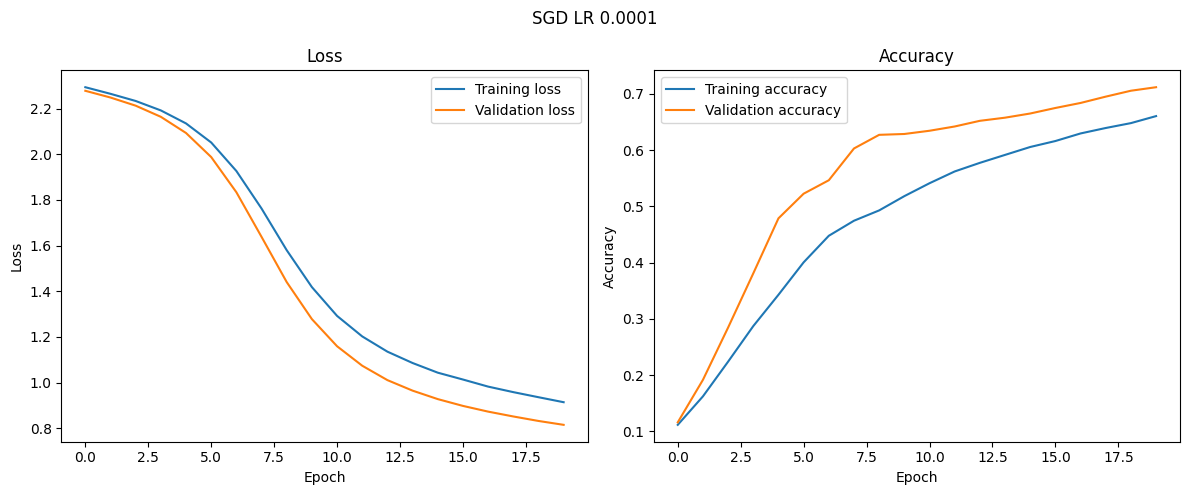

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3406 - loss: 1.9886 - val_accuracy: 0.6296 - val_loss: 1.2832
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6062 - loss: 1.0661 - val_accuracy: 0.7063 - val_loss: 0.8284
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6889 - loss: 0.8442 - val_accuracy: 0.7456 - val_loss: 0.7220
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7314 - loss: 0.7502 - val_accuracy: 0.7648 - val_loss: 0.6620
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7518 - loss: 0.6940 - val_accuracy: 0.7792 - val_loss: 0.6222
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7684 - loss: 0.6529 - val_accuracy: 0.7912 - val_loss: 0.5879
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7793 - loss: 0.6189 - val_accuracy: 0.7977 - val_loss: 0.5703
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7895 - loss: 0

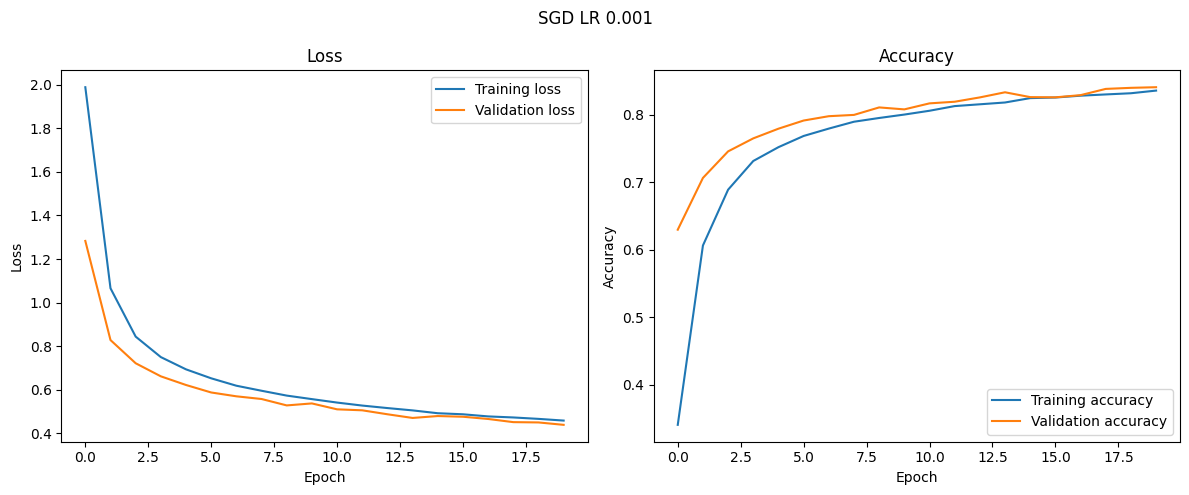

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6630 - loss: 0.9235 - val_accuracy: 0.7763 - val_loss: 0.6056
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7812 - loss: 0.5908 - val_accuracy: 0.7796 - val_loss: 0.5556
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8127 - loss: 0.5083 - val_accuracy: 0.8158 - val_loss: 0.4814
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8306 - loss: 0.4620 - val_accuracy: 0.8289 - val_loss: 0.4608
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8441 - loss: 0.4292 - val_accuracy: 0.8591 - val_loss: 0.3907
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8518 - loss: 0.4086 - val_accuracy: 0.8571 - val_loss: 0.3887
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8594 - loss: 0.3881 - val_accuracy: 0.8595 - val_loss: 0.3812
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8641 - loss: 0

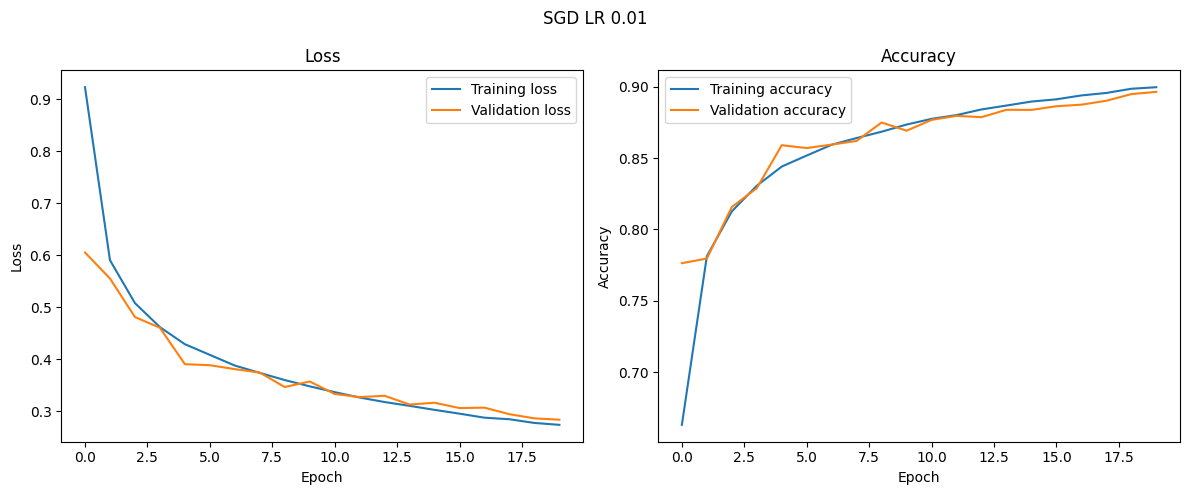

                      name  train_accuracy  train_loss  validation_accuracy  validation_loss  epochs_trained  training_time
                 Basmodell        0.962750    0.106622             0.905833         0.302344               7      76.455451
         Förbättrad modell        0.960521    0.108154             0.917333         0.269844               7      82.896507
Förbättrad modell 2 (Adam)        0.945979    0.143244             0.919250         0.252821               8     103.992963
            Adam LR 0.0001        0.927562    0.198125             0.921083         0.223854              20     265.836506
             Adam LR 0.001        0.945979    0.143244             0.919250         0.252821               8     102.320499
              Adam LR 0.01        0.873208    0.341232             0.880333         0.338419               7      94.484718
             SGD LR 0.0001        0.660646    0.914236             0.712000         0.815132              20     229.911976
        

In [18]:
# Experiment med SGD och olika inlärningshastigheter

model_sgd_low, h_sgd_low, r_sgd_low = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="SGD LR 0.0001", optimizer="sgd", learning_rate=0.0001)
model_sgd, h_sgd, r_sgd = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="SGD LR 0.001", optimizer="sgd", learning_rate=0.001)
model_sgd_high, h_sgd_high, r_sgd_high = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="SGD LR 0.01", optimizer="sgd", learning_rate=0.01)
results.extend([r_sgd_low, r_sgd, r_sgd_high])

print(pd.DataFrame(results).to_string(index=False))

### Experiment RMDprop med LR 0,0001, 0,001 och 0,01

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7321 - loss: 0.7579 - val_accuracy: 0.8210 - val_loss: 0.4857
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8314 - loss: 0.4731 - val_accuracy: 0.8438 - val_loss: 0.4262
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8552 - loss: 0.4059 - val_accuracy: 0.8597 - val_loss: 0.3838
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8668 - loss: 0.3725 - val_accuracy: 0.8675 - val_loss: 0.3633
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8784 - loss: 0.3440 - val_accuracy: 0.8782 - val_loss: 0.3338
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8838 - loss: 0.3290 - val_accuracy: 0.8781 - val_loss: 0.3322
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8884 - loss: 0.3127 - val_accuracy: 0.8815 - val_loss: 0.3260
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8935 - loss: 0

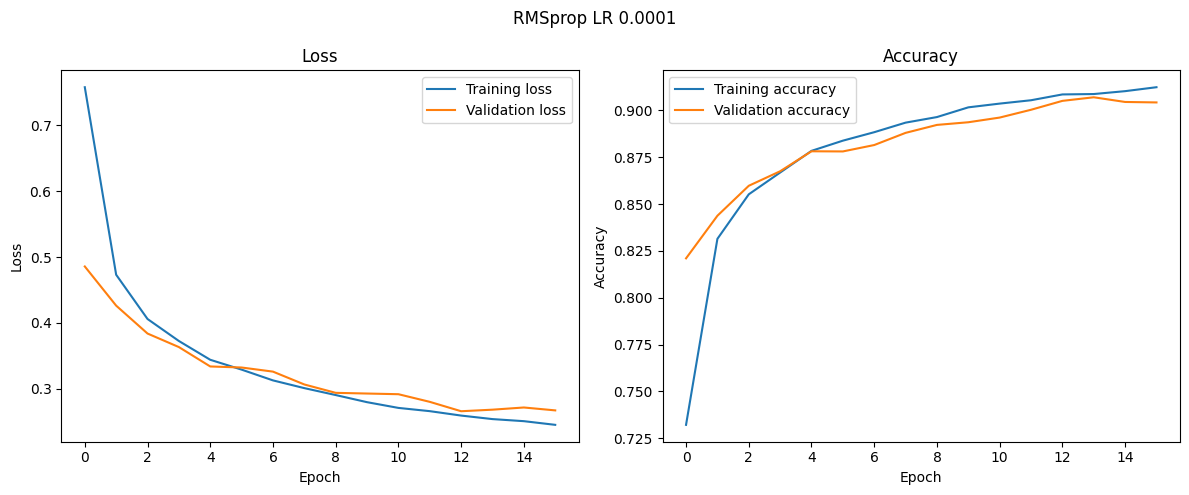

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8298 - loss: 0.4732 - val_accuracy: 0.8775 - val_loss: 0.3313
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8910 - loss: 0.3043 - val_accuracy: 0.8981 - val_loss: 0.2777
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9085 - loss: 0.2581 - val_accuracy: 0.8987 - val_loss: 0.2688
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9155 - loss: 0.2365 - val_accuracy: 0.9103 - val_loss: 0.2504
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9200 - loss: 0.2222 - val_accuracy: 0.9087 - val_loss: 0.2571
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9259 - loss: 0.2107 - val_accuracy: 0.9147 - val_loss: 0.2457
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9280 - loss: 0.2080 - val_accuracy: 0.9170 - val_loss: 0.2470
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9290 - loss: 

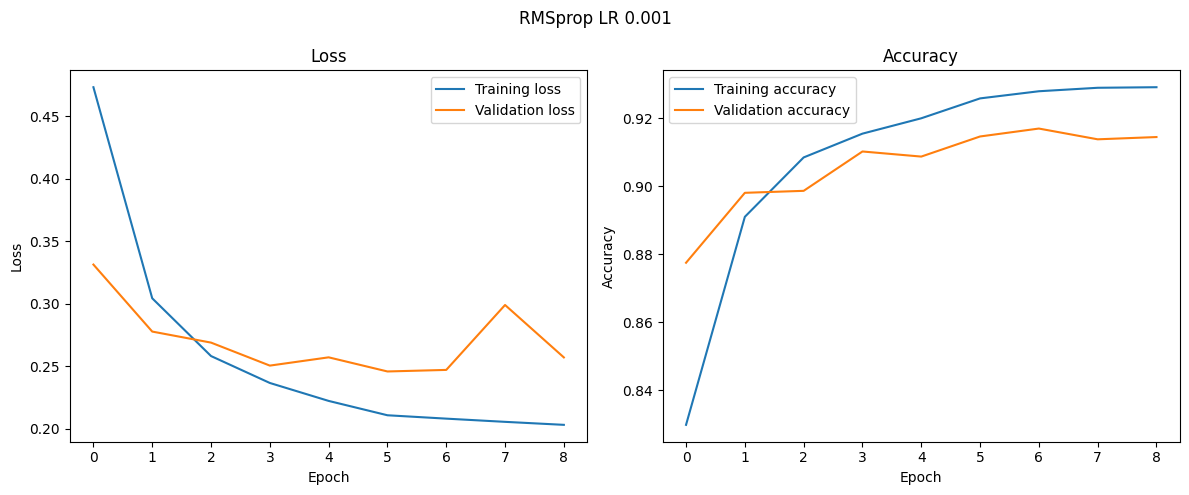

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8127 - loss: 0.5400 - val_accuracy: 0.8353 - val_loss: 0.4409
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8446 - loss: 0.4457 - val_accuracy: 0.8280 - val_loss: 0.4594
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8443 - loss: 0.4487 - val_accuracy: 0.8263 - val_loss: 0.4778
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8398 - loss: 0.4680 - val_accuracy: 0.8422 - val_loss: 0.4248
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8370 - loss: 0.4798 - val_accuracy: 0.8417 - val_loss: 0.4693
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8372 - loss: 0.4911 - val_accuracy: 0.8190 - val_loss: 0.4689
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8359 - loss: 0.4905 - val_accuracy: 0.8570 - val_loss: 0.4575

Resultat för RMSprop LR 0.01:
Antal epoker:        7
Train accuracy:      0.8359
T

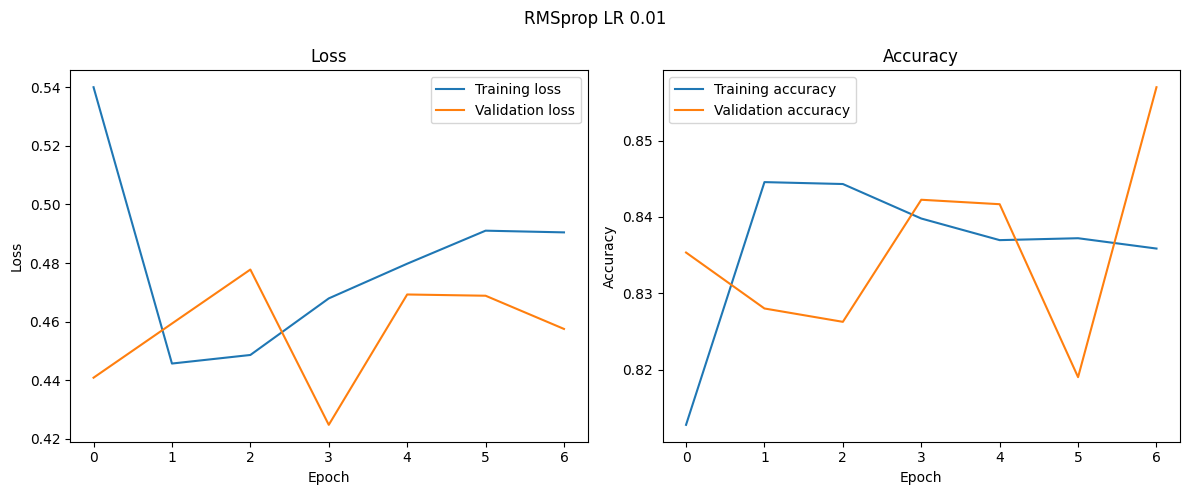

                      name  train_accuracy  train_loss  validation_accuracy  validation_loss  epochs_trained  training_time
                 Basmodell        0.962750    0.106622             0.905833         0.302344               7      76.455451
         Förbättrad modell        0.960521    0.108154             0.917333         0.269844               7      82.896507
Förbättrad modell 2 (Adam)        0.945979    0.143244             0.919250         0.252821               8     103.992963
            Adam LR 0.0001        0.927562    0.198125             0.921083         0.223854              20     265.836506
             Adam LR 0.001        0.945979    0.143244             0.919250         0.252821               8     102.320499
              Adam LR 0.01        0.873208    0.341232             0.880333         0.338419               7      94.484718
             SGD LR 0.0001        0.660646    0.914236             0.712000         0.815132              20     229.911976
        

In [19]:
# Experiment med RMSprop och olika inlärningshastigheter

model_rms_low, h_rms_low, r_rms_low = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="RMSprop LR 0.0001", optimizer="rmsprop", learning_rate=0.0001)
model_rms, h_rms, r_rms = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="RMSprop LR 0.001", optimizer="rmsprop", learning_rate=0.001)
model_rms_high, h_rms_high, r_rms_high = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="RMSprop LR 0.01", optimizer="rmsprop", learning_rate=0.01)
results.extend([r_rms_low, r_rms, r_rms_high])

print(pd.DataFrame(results).to_string(index=False))

In [24]:
display(pd.DataFrame(results)
    .sort_values("validation_accuracy", ascending=False)
    .style.format({
    "train_accuracy":      "{:.4f}",
    "train_loss":          "{:.4f}",
    "validation_accuracy": "{:.4f}",
    "validation_loss":     "{:.4f}",
    "epochs_trained":      "{:.0f}",
    "training_time":       "{:.1f}s"
}).highlight_max(subset=["validation_accuracy"], color="lightgreen")
  .highlight_min(subset=["validation_loss"], color="lightblue")
  .set_caption("Sammanfattning av alla experiment")
  .set_table_styles([{"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold")]}]))

,name,train_accuracy,train_loss,validation_accuracy,validation_loss,epochs_trained,training_time
3,Adam LR 0.0001,0.9276,0.1981,0.9211,0.2239,20,265.8s
2,Förbättrad modell 2 (Adam),0.9460,0.1432,0.9193,0.2528,8,104.0s
4,Adam LR 0.001,0.9460,0.1432,0.9193,0.2528,8,102.3s
1,Förbättrad modell,0.9605,0.1082,0.9173,0.2698,7,82.9s
10,RMSprop LR 0.001,0.9292,0.2030,0.9145,0.2570,9,117.4s
0,Basmodell,0.9628,0.1066,0.9058,0.3023,7,76.5s
9,RMSprop LR 0.0001,0.9124,0.2452,0.9043,0.2671,16,203.9s
8,SGD LR 0.01,0.8997,0.2740,0.8965,0.2839,20,234.2s
5,Adam LR 0.01,0.8732,0.3412,0.8803,0.3384,7,94.5s
11,RMSprop LR 0.01,0.8359,0.4905,0.8570,0.4575,7,87.5s


In [ ]:
# Testar bästa modellen på testdatan



## 7 Analys och slutsatser för fokusområde optimerare och inlärningshastighet

Adam:   
Adam med låg inlärningshastighet 0,0001, har högst accuracy på valideringsdata och tränings- och valideringskurvorna följer varandra väl. Modellen generaliserar bäst av de tre men är den som använder flest epoker och tar längst tid. Adam med hög inlärningshastighet har instabila kutvor och ser ut att hoppa över bra minima. Adam med mellanhastigheten som är en vanlig standard börjar överanpassa vid epok 3 men tar mindre än halva tiden än den med låg inlärningshastighet och kan vara en bra kompromiss.

SGD:   
Med låg inlärningshastighet når SGD inte upp i så hög accuracy på valideringsdatan, 0,712. Kurvorna visar att modellen inte har lärt sig klart. Med högre inlärningshastighet hinner SGD-modellerna lära sig mer och accuracy på valideringsdatan ökar men ligger fortfarande bland de lägre och under basmodellens. 

RMSprop:    
RMSprop visar ett liknande resultat som Adam där tränings- och valideringskurvorna följer varandra väl i den lägsta inlärningshastiheten medan bästa accuracy på valideringsdatan får i modellen med inlärningshastigheten 0,001. 

**Slutsats**  
SGD är den enklaste optimeraren som bara tar steg baserat på aktuell gradient men den tar inte hänsyn till tidigare steg och blir därför långsammre än de övriga. RMSprop kan anpassa steglängden utifrån tidigare gradienter vilket gör den snabbare. Adam kan också anpassa steglängden men den kan dessutom minnas i vilken riktning stegen tagits och det gör den snabbare att konvergera än SGD och RMSprop.  

Valet av inlärningshastighet påverkar optimerarna olika. SGD är känsligast eftersom den saknar adaptiv anpassning och en för låg inlärningshastighet gör att modellen inte hinner lära sig tillräckligt medan en högre krävs för att nå acceptabel accuracy. RMSprop och Adam är mer förlåtande tack vare sin adaptiva steglängd, men en för hög inlärningshastighet ger instabila kurvor för båda. Generellt gäller att lägre inlärningshastighet ger jämnare kurvor och bättre generalisering men kräver fler epoker, medan högre inlärningshastighet konvergerar snabbare men riskerar att hoppa över bra minima.
